In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = {
    "text": [
        "I absolutely loved this movie",
        "The movie was fantastic and enjoyable",
        "Amazing experience, I would watch it again",
        "This film was excellent",
        "I really enjoyed the story",
        "Great acting and wonderful direction",
        "The movie was boring and disappointing",
        "I hated this movie",
        "Terrible film, waste of time",
        "The story was awful",
        "Very disappointing experience",
        "Bad acting and poor direction",
        "I loved the amazing performance",
        "Fantastic movie with great acting",
        "Excellent story and beautiful visuals",
        "Wonderful and enjoyable film",
        "I did not like this movie",
        "The movie was horrible",
        "Awful experience and boring story",
        "Very bad movie"
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0,
        1, 1, 1, 1,
        0, 0, 0, 0
    ]
}

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["sentiment"].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (20, 2)

Class distribution:
sentiment
1    10
0    10
Name: count, dtype: int64

First 5 rows:
                                         text  sentiment
0               I absolutely loved this movie          1
1       The movie was fantastic and enjoyable          1
2  Amazing experience, I would watch it again          1
3                     This film was excellent          1
4                  I really enjoyed the story          1


In [3]:
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 16
Testing samples: 4
Training class distribution:
sentiment
0    8
1    8
Name: count, dtype: int64

Testing class distribution:
sentiment
0    2
1    2
Name: count, dtype: int64


In [4]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

Training TF-IDF shape: (16, 34)
Testing TF-IDF shape: (4, 34)
Number of features: 34


In [5]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_tfidf, y_train)

logistic_pred = logistic_model.predict(X_test_tfidf)
logistic_prob = logistic_model.predict_proba(X_test_tfidf)[:, 1]

print("Logistic Regression predictions:", logistic_pred)
print("Actual values:", y_test.to_numpy())
print("Logistic Regression accuracy:", accuracy_score(y_test, logistic_pred))

Logistic Regression predictions: [0 0 0 1]
Actual values: [0 0 1 1]
Logistic Regression accuracy: 0.75


In [6]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, logistic_pred, target_names=["Negative", "Positive"]))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      1.00      0.80         2
    Positive       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



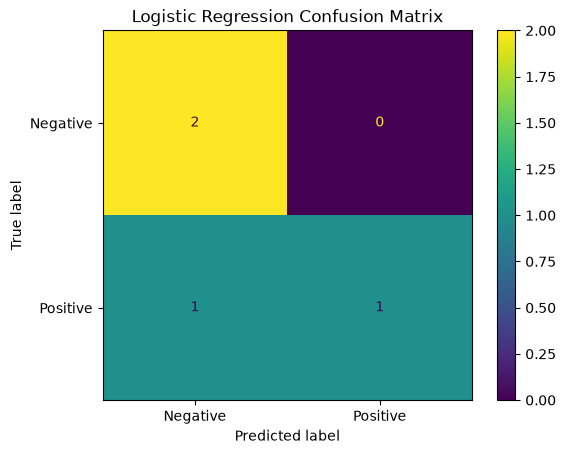

[[2 0]
 [1 1]]


In [7]:
cm = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(cm)

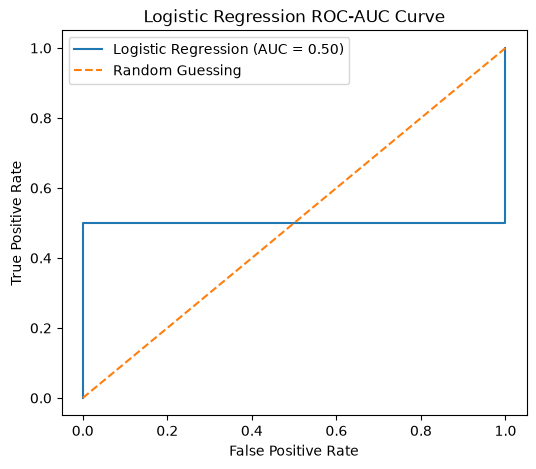

Logistic Regression ROC-AUC: 0.5


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_prob)
logistic_auc = roc_auc_score(y_test, logistic_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {logistic_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC-AUC Curve")
plt.legend()
plt.show()

print("Logistic Regression ROC-AUC:", logistic_auc)

In [9]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train_tfidf, y_train)

rf_pred = random_forest.predict(X_test_tfidf)

print("Random Forest predictions:", rf_pred)
print("Actual values:", y_test.to_numpy())
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Random Forest predictions: [0 1 0 1]
Actual values: [0 0 1 1]
Random Forest accuracy: 0.5


In [10]:
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Negative", "Positive"]
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         2
    Positive       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [11]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1": f1_score(y_test, logistic_pred)
}

rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred)
}

comparison = pd.DataFrame(
    [logistic_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"]
)

print(comparison)

                     Accuracy  Precision  Recall        F1
Logistic Regression      0.75        1.0     0.5  0.666667
Random Forest            0.50        0.5     0.5  0.500000


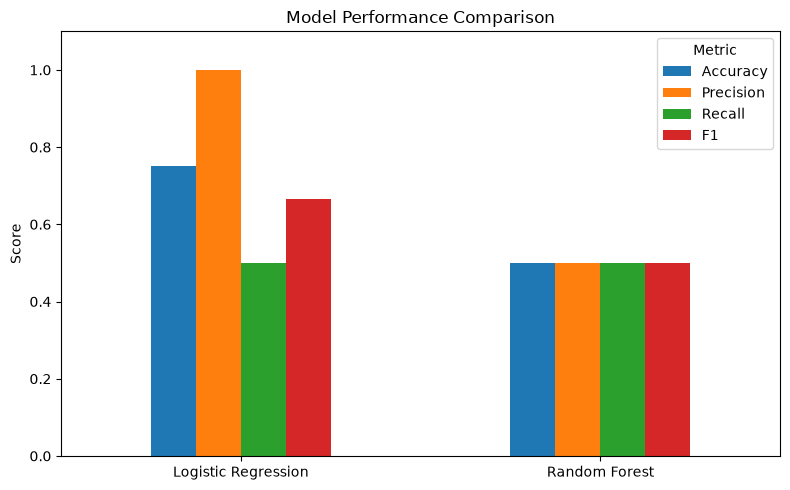

In [12]:
comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


## Capstone Conclusion

The sentiment classification capstone was completed using TF-IDF text features with Logistic Regression and Random Forest classifiers.

Logistic Regression achieved:
- Accuracy: 0.75
- Precision: 1.00
- Recall: 0.50
- F1-score: 0.67
- ROC-AUC: 0.50

Random Forest achieved:
- Accuracy: 0.50
- Precision: 0.50
- Recall: 0.50
- F1-score: 0.50

The results show that model performance should be evaluated using multiple metrics rather than accuracy alone. Since the test set contains only 4 samples, these results should not be treated as a reliable estimate of real-world performance.

The capstone demonstrates the complete workflow from text preprocessing and model training to evaluation and model comparison.